### a)

#### Problema directo e inverso:¿Cual es la dificultad del problema?

A diferencia del problema directo, en el cual se conoce el modelo fisico, los parametros y cuya dificultad suele ser matemática o númerica. Los problemas inversos, donde muchas veces no se conocen los parametros que componen al problema, suelen ser mal condicionados, es decir: Pequeñas variaciones o ruidos en la señal pueden generar cambios considerables o impredecibles en los parametros estimados. Ademas, considerando el problema en cuestion, distintas combinaciones de $\gamma$ y $k$ podrian producir señales identicas, por lo que se pierde la unicidad de la solución

#### Aprendizaje supervisado: ¿Es necesario conocer las etiquetas para un poblema inverso? 

Es importante considerar el contexto. Si se trata de resolver en un laboratorio, normalmente estas etiquetas no se tienen, se deben inferir. Pero si consideramos el proceso de entrenamiento de un modelo, es necesario conocer de antemano las etiquetas, pues entender que para el aprendizaje supervisado se utilizan como ejemplo problemas cuya solución ya es conocida (especificamente sus 'etiquetas') como material de aprendizaje. Por lo que en el contexto del aprendizaje supervisado conocer las etiquetas es importante cuando se trata de modelar un problema inverso

#### Conjuntos de entrenamiento y validación: Explique por qué se separan los datos en 'train' y 'test'

Si usamos los mismos datos para enseñarle al modelo y para evaluar qué tan bueno es, el modelo podría simplemente "memorizar" los datos de entrada (lo que llamamos sobreajuste o overfitting). Por lo que separar los datos en Train y Test sirve para evaluar la capacidad de generalización del modelo. El conjunto de validación actúa como una 'prueba sorpresa' con datos que el modelo jamás vio durante su entrenamiento.

#### Función de perdida: explique por qué es necesario definir un error cuadrático medio

Sabemos que el modelo en un principio arrojara predicciones al azar $(\gamma ' , k')$. Por lo que necesitamos una metrica que le diga al modelo que tan alejado esta de la realidad $(\gamma , k)$. Para esto se utiliza el error cuadratico medio porque al elevar la diferencia al cuadrado, nos aseguramos que los errores no se cancelen entre si, ademas este penaliza mucho mas los errore grandes lo que obliga al algoritmo de optimizacion a corregir rapidamente las predicciones que esten muy erradas. 



Generando señales y añadiendo ruido experimental...
Señales generadas y ruido añadido correctamente.


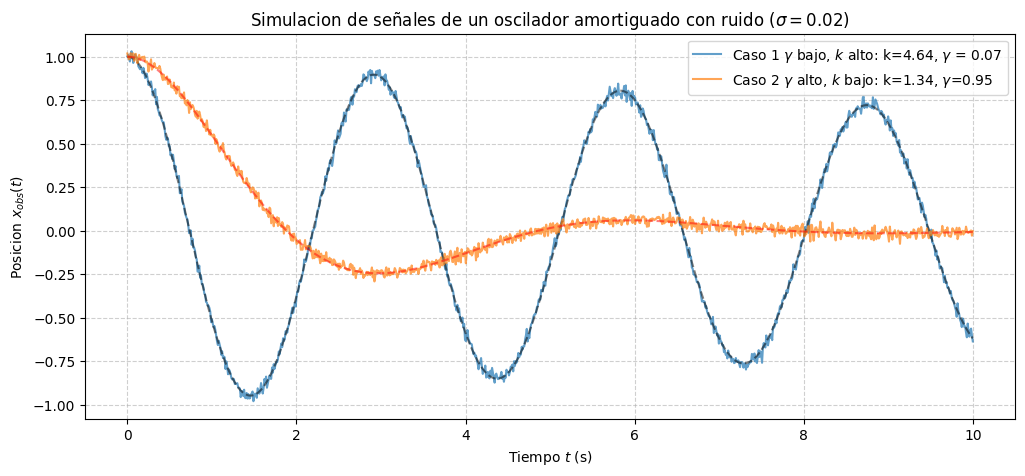

In [ ]:
# b) Realizamos por pasos

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#Definimos los valores iniciales 

N_señales = 3000    #Numero de señales
N_t = 1000          #puntos por señal
t_span = (0, 10 )   #intervalo de tiempo
t_eval = np.linspace(t_span[0], t_span[1], N_t)   

m = 1.0 
x0 = [1.0, 0.0] #condiciones iniciales para x(t) y x'(t)


# Parametros aleatorios (usamos distribuciones uniformes)

np.random.seed(0)
gamma_array = np.random.uniform(0.05, 1.0, N_señales) 
k_array = np.random.uniform(1.0, 5.0, N_señales)


dataset_clean = np.zeros((N_señales, N_t)) # Matriz para almacenar las señales limpias
dataset_noisy = np.zeros((N_señales, N_t)) # Matriz para almacenar las señales con ruido



#definimos el sistema 

def oscilador_amortiguado(t, y, gamma, k, m):
    x, v = y
    dxdt = v 
    dvdt = - (gamma/m)*v - (k/m)*x 
    return [dxdt, dvdt]

print("Generando señales y añadiendo ruido experimental...")

for i in range(N_señales):

    gamma_i = gamma_array[i]
    k_i = k_array[i]

    #resolvemos el problema numerico para cada señal

    sol = solve_ivp(oscilador_amortiguado, t_span, x0, t_eval = t_eval, args = (gamma_i, k_i, m), method='RK45')

    #guardamos la señal 'ideal'

    x_ideal = sol.y[0]
    dataset_clean[i, :] = x_ideal

    ruido = np.random.normal(0, 0.02, N_t) #media = 0 y desviacion estandar = 0.02 

    dataset_noisy[i, :] = x_ideal + ruido

print("Señales generadas y ruido añadido correctamente.")

#Graficamos las señales para los casos extremos por casos 

plt.figure(figsize=(12, 5))

#Caso 1: Amortiguamiento gamma bajo y frecuencia k alta 

idx_A = np.intersect1d(np.where(k_array > 4.5 ), np.where(gamma_array < 0.1))[0] 
plt.plot(t_eval, dataset_noisy[idx_A, :], label = rf'Caso 1 $\gamma$ bajo, $k$ alto: k={k_array[idx_A]:.2f}, $\gamma$ = {gamma_array[idx_A]:.2f}', alpha = 0.7 ) 
plt.plot(t_eval, dataset_clean[idx_A], 'k--', alpha=0.5)   

#Caso 2: amortiguamiento gamma alto y frecuencia k baja 

idx_B = np.intersect1d(np.where(k_array < 1.5), np.where(gamma_array > 0.9))[0]
plt.plot(t_eval, dataset_noisy[idx_B], label=rf"Caso 2 $\gamma$ alto, $k$ bajo: k={k_array[idx_B]:.2f}, $\gamma$={gamma_array[idx_B]:.2f}", alpha=0.7)
plt.plot(t_eval, dataset_clean[idx_B], 'r--', alpha=0.5)

plt.title(r"Simulacion de señales de un oscilador amortiguado con ruido ($\sigma=0.02$)")
plt.xlabel("Tiempo $t$ (s)")
plt.ylabel("Posicion $x_{obs}(t)$")
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.legend(loc= 'upper right')
plt.show()


In [8]:
# c) 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error


#  Preparacion y division de datos
X = dataset_noisy
y = np.column_stack((gamma_array, k_array))  # Matriz de dimensión (3000, 2)

# Separación 80% entrenamiento y 20% validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Separamos las etiquetas reales de prueba para calcular los RMSE individuales al final
gamma_test = y_test[:, 0]
k_test = y_test[:, 1]

print(f"Datos de entrenamiento: {X_train.shape[0]} señales.")
print(f"Datos de validación: {X_test.shape[0]} señales.\n")

#  Entrenamiento random forest
print("Entrenando RandomForestRegressor (esto puede tardar unos segundos)...")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predicciones del Random Forest
y_pred_rf = rf_model.predict(X_test)
gamma_pred_rf = y_pred_rf[:, 0]
k_pred_rf = y_pred_rf[:, 1]


#  ENTRENAMIENTO DE RED NEURONAL (MLP) 
print("Entrenando MLPRegressor (Red Neuronal)...")

# Usamos una arquitectura simple de dos capas ocultas (por ejemplo, 100 y 50 neuronas)

mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=500, random_state=42)

mlp_model.fit(X_train, y_train)

# Predicciones de la Red Neuronal
y_pred_mlp = mlp_model.predict(X_test)

gamma_pred_mlp = y_pred_mlp[:, 0]

k_pred_mlp = y_pred_mlp[:, 1]



#  Reporte de desempeño (RMSE) 
# Usamos root_mean_squared_error directamente de scikit-learn
rmse_gamma_rf = root_mean_squared_error(gamma_test, gamma_pred_rf)
rmse_k_rf = root_mean_squared_error(k_test, k_pred_rf)

rmse_gamma_mlp = root_mean_squared_error(gamma_test, gamma_pred_mlp)
rmse_k_mlp = root_mean_squared_error(k_test, k_pred_mlp)

print("\n" + "="*40)
print("             REPORTE DE DESEMPEÑO")
print("="*40)
print("Modelo 1: Random Forest Regressor")
print(f"  -> RMSE en Gamma: {rmse_gamma_rf:.4f}")
print(f"  -> RMSE en K:     {rmse_k_rf:.4f}")
print("-"*40)
print("Modelo 2: Multi-Layer Perceptron (Red Neuronal)")
print(f"  -> RMSE en Gamma: {rmse_gamma_mlp:.4f}")
print(f"  -> RMSE en K:     {rmse_k_mlp:.4f}")
print("="*40)


Datos de entrenamiento: 2400 señales.
Datos de validación: 600 señales.

Entrenando RandomForestRegressor (esto puede tardar unos segundos)...
Entrenando MLPRegressor (Red Neuronal)...

             REPORTE DE DESEMPEÑO
Modelo 1: Random Forest Regressor
  -> RMSE en Gamma: 0.0158
  -> RMSE en K:     0.0981
----------------------------------------
Modelo 2: Multi-Layer Perceptron (Red Neuronal)
  -> RMSE en Gamma: 0.0303
  -> RMSE en K:     0.0393


<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
C:\Users\reyes_a\AppData\Local\Temp\ipykernel_19180\4135150764.py:37: SyntaxWarning: invalid escape sequence '\s'
  print(f"Evaluando rendimiento con ruido experimental \sigma = {sigma}...")


Evaluando rendimiento con ruido experimental \sigma = 0.0...
Evaluando rendimiento con ruido experimental \sigma = 0.01...
Evaluando rendimiento con ruido experimental \sigma = 0.02...
Evaluando rendimiento con ruido experimental \sigma = 0.05...
Evaluando rendimiento con ruido experimental \sigma = 0.1...


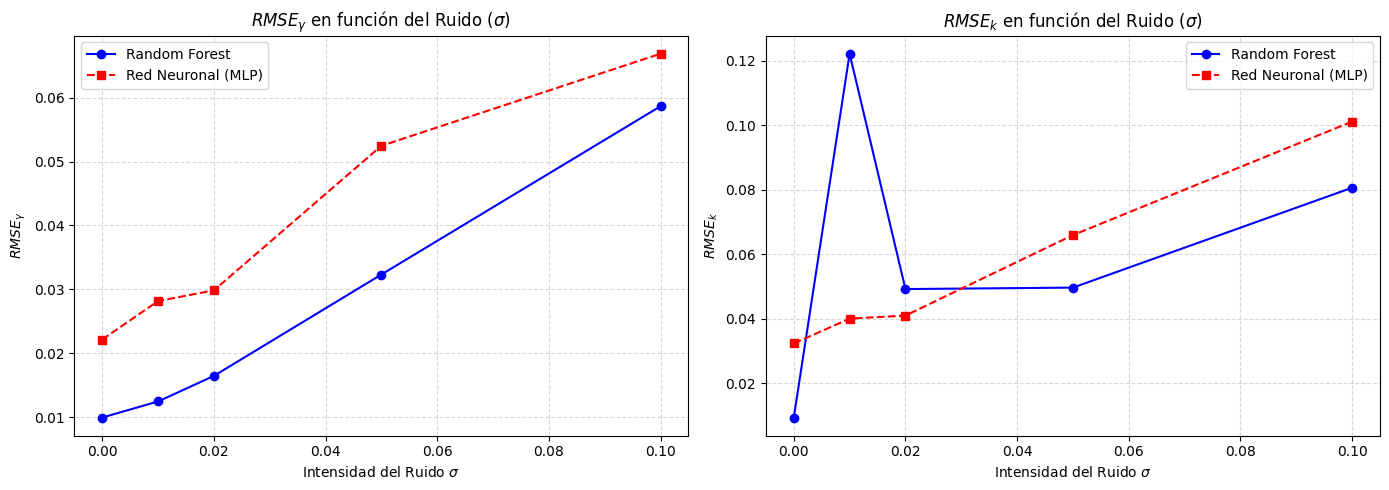

In [ ]:
# d) 



# Cconfiguracion base
N_signals = 3000
N_t = 1000
t_span = (0, 10)
t_ev = np.linspace(t_span[0], t_span[1], N_t)
m = 1.0
x0 = [1.0, 0.0]

np.random.seed(0)
gamma_array = np.random.uniform(0.05, 1.0, N_signals)
k_array = np.random.uniform(1.0, 5.0, N_signals)
y = np.column_stack((gamma_array, k_array))

# Arreglo con los diferentes niveles de ruido a evaluar
sigmas = [0.0, 0.01, 0.02, 0.05, 0.10]

# Listas para almacenar los resultados de cada experimento
rf_rmse_gamma, rf_rmse_k = [], []
mlp_rmse_gamma, mlp_rmse_k = [], []

# 1. Generamos primero las 3000 señales limpias base para ahorrar tiempo
dataset_clean = np.zeros((N_signals, N_t))



def oscilador_amortiguado(t, y_vec, gamma, k, m):
    x, v = y_vec
    return [v, -(gamma/m)*v - (k/m)*x]

for i in range(N_signals):
    sol = solve_ivp(oscilador_amortiguado, t_span, x0, t_eval=t_ev, args=(gamma_array[i], k_array[i], m), method='RK45')
    dataset_clean[i, :] = sol.y[0]

# 2. Evaluamos cada sigma
for sigma in sigmas:
    print(f"Evaluando rendimiento con ruido experimental \sigma = {sigma}...")
    
    # Añadir el ruido correspondient
    if sigma == 0.0:
        X = dataset_clean
    else:
        ruido = np.random.normal(0, sigma, size=(N_signals, N_t))
        X = dataset_clean + ruido
        
    # Dividir en Train (80%) y Test (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    gamma_test = y_test[:, 0]
    k_test = y_test[:, 1]
    
    # Random Forest 
    rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_rmse_gamma.append(root_mean_squared_error(gamma_test, y_pred_rf[:, 0]))
    rf_rmse_k.append(root_mean_squared_error(k_test, y_pred_rf[:, 1]))
    
    #  Red Neuronal (MLP) 
    mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', max_iter=400, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred_mlp = mlp.predict(X_test)
    mlp_rmse_gamma.append(root_mean_squared_error(gamma_test, y_pred_mlp[:, 0]))
    mlp_rmse_k.append(root_mean_squared_error(k_test, y_pred_mlp[:, 1]))

#  GRÁFICOS DE DESEMPEÑO EN FUNCIÓN DE SIGMA 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para Gamma
ax[0].plot(sigmas, rf_rmse_gamma, 'o-', label='Random Forest', color='blue')
ax[0].plot(sigmas, mlp_rmse_gamma, 's--', label='Red Neuronal (MLP)', color='red')
ax[0].set_title(r'$RMSE_{\gamma}$ en función del Ruido ($\sigma$)')
ax[0].set_xlabel(r'Intensidad del Ruido $\sigma$')
ax[0].set_ylabel(r'$RMSE_{\gamma}$')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend()

# Gráfico para K
ax[1].plot(sigmas, rf_rmse_k, 'o-', label='Random Forest', color='blue')
ax[1].plot(sigmas, mlp_rmse_k, 's--', label='Red Neuronal (MLP)', color='red')
ax[1].set_title(r'$RMSE_{k}$ en función del Ruido ($\sigma$)')
ax[1].set_xlabel(r'Intensidad del Ruido $\sigma$')
ax[1].set_ylabel(r'$RMSE_{k}$')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

#### ¿Qué parámetro es mas dificil predecir?

Viendo las gráficas, la constante del resorte ($k$) es definitivamente el parámetro más difícil de calcular para el modelo. Si notamos los ejes, el error para $\gamma$ ($RMSE_{\gamma}$) se mantiene relativamente bajo, por debajo de $0.07$, incluso con el ruido más alto ($\sigma = 0.10$). En cambio, el error para $k$ ($RMSE_{k}$) se dispara por encima de $0.10$. Esto es debido a que el amortiguamiento $\gamma$ controla la 'silueta' o envolvente general de la señal a través de la exponencial $$A(t) \propto e^{-\frac{\gamma}{2m}t}$$

Esta caída general es muy obvia y fácil de notar para los algoritmos, aunque haya ruido.

Sin embargo, $k$ controla la rapidez con la que vibra el sistema, es decir, su frecuencia amortiguada: $$\omega_d = \sqrt{\frac{k}{m} - \left(\frac{\gamma}{2m}\right)^2}$$
Cuando se introduce ruido gaussiano, este altera los picos locales y los momentos exactos en que la curva cruza por cero. Al borrarse esos detalles finos de alta frecuencia, al modelo le cuesta mucho mas descifrar el valor real de $k$.


#### ¿Cómo se nota el sobreajuste (Overfitting) en el gráfico?

El sobreajuste aquí se ve como una "trampa" de memoria. Si midiéramos el error dentro de los datos que usamos para entrenar, sería casi cero, pero en nuestras gráficas (que usan los datos de validación) el error sube y sube a medida que aumentamos el ruido $\sigma$. Y como los modelos de M.L. (sobre todo Random Forest) son matemáticamente superflexibles, cuando ven mucho ruido empiezan a memorizar las imperfecciones aleatorias de esas 2400 señales específicas en lugar de aprenderse la ecuación diferencial real. Al pasarles el conjunto de validación (el 20% restante), el ruido sigue la misma campana de Gauss pero con números y posiciones completamente distintas. Como el modelo solo memorizó el ruido anterior y no la física subyacente, sus reglas fallan, pierde su capacidad de generalizar y el $RMSE$ se dispara hacia arriba.